In [1]:

# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


In [3]:
import os
import scipy.io as sio
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/CPM-15")
IMG_DIR = BASE_PATH / "Images"
LBL_DIR = BASE_PATH / "Labels"

def inspect_cpm15_sample(img_idx):
    img_name = f"image_{img_idx:02d}.png"
    lbl_name = f"image_{img_idx:02d}.mat"
    
    img_path = IMG_DIR / img_name
    lbl_path = LBL_DIR / lbl_name
    
    print(f"\n=== Investigating CPM-15 Pair: {img_name} ===")
    
    # 1. Load Image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"  [Image Shape]: {img.shape}")

    # 2. Load .mat Label
    mat = sio.loadmat(str(lbl_path))
    # Filter out metadata keys
    keys = [k for k in mat.keys() if not k.startswith('__')]
    print(f"  [Mat Keys]: {keys}")
    
    # CPM-15 usually has 'inst_map' or 'label'
    for key in keys:
        data = mat[key]
        if isinstance(data, np.ndarray):
            unique_vals = len(np.unique(data))
            print(f"    -> Key '{key}': Shape {data.shape}, Unique IDs: {unique_vals}")

# Inspect the first few samples
for i in range(3):
    inspect_cpm15_sample(i)


=== Investigating CPM-15 Pair: image_00.png ===
  [Image Shape]: (488, 643, 3)
  [Mat Keys]: ['inst_map']
    -> Key 'inst_map': Shape (488, 643), Unique IDs: 352

=== Investigating CPM-15 Pair: image_01.png ===
  [Image Shape]: (490, 488, 3)
  [Mat Keys]: ['inst_map']
    -> Key 'inst_map': Shape (490, 488), Unique IDs: 128

=== Investigating CPM-15 Pair: image_02.png ===
  [Image Shape]: (587, 751, 3)
  [Mat Keys]: ['inst_map']
    -> Key 'inst_map': Shape (587, 751), Unique IDs: 257


In [4]:
import os
import glob
import numpy as np
import zarr
import pandas as pd
import scipy.io as sio
import cv2
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
base_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/CPM-15")
img_dir = base_path / "Images"
label_dir = base_path / "Labels"

# Output Path
output_base_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/cpm15/zarr_data")

PATCH_SIZE = 512
NUM_WORKERS = 8 # Small dataset, low worker count is fine

# ---------------------------------------------------------------------
# 2. Helper Functions
# ---------------------------------------------------------------------
def get_smart_coords(length, crop_size):
    if length <= crop_size:
        return [0]
    coords = list(range(0, length - crop_size, crop_size))
    coords.append(length - crop_size)
    return sorted(list(set(coords)))

def process_and_stack_cpm(args):
    img_path, label_path, file_name, out_dir = args
    
    try:
        # --- A. Load ---
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mat = sio.loadmat(str(label_path))
        # CPM-15 usually uses 'inst_map'
        inst_map = mat['inst_map'].astype(np.int32)
        
        h, w = img.shape[:2]
        
        # --- B. Pad to ensure at least PATCH_SIZE ---
        pad_h = max(0, PATCH_SIZE - h)
        pad_w = max(0, PATCH_SIZE - w)
        if pad_h > 0 or pad_w > 0:
            img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), constant_values=0)
            inst_map = np.pad(inst_map, ((0, pad_h), (0, pad_w)), constant_values=0)
            h, w = img.shape[:2]

        # --- C. Generate Crops ---
        y_points = get_smart_coords(h, PATCH_SIZE)
        x_points = get_smart_coords(w, PATCH_SIZE)
        
        img_stack, nuc_stack, metadata_list = [], [], []
        
        for y in y_points:
            for x in x_points:
                crop_img = img[y : y+PATCH_SIZE, x : x+PATCH_SIZE]
                crop_nuc = inst_map[y : y+PATCH_SIZE, x : x+PATCH_SIZE]
                
                if crop_img.shape == (PATCH_SIZE, PATCH_SIZE, 3):
                    img_stack.append(crop_img)
                    nuc_stack.append(crop_nuc)
                    metadata_list.append({
                        'original_file': file_name,
                        'x': x, 'y': y
                    })

        final_imgs = np.stack(img_stack, axis=0)
        final_nucs = np.stack(nuc_stack, axis=0)

        # --- D. Save ---
        slide_out_path = out_dir / file_name
        slide_out_path.mkdir(parents=True, exist_ok=True)
        
        z_img = zarr.open(slide_out_path / 'images.zarr', mode='w', shape=final_imgs.shape,
                          chunks=(1, PATCH_SIZE, PATCH_SIZE, 3), dtype='uint8',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_img[:] = final_imgs
        
        z_nuc = zarr.open(slide_out_path / 'nuclei_masks.zarr', mode='w', shape=final_nucs.shape,
                          chunks=(1, PATCH_SIZE, PATCH_SIZE), dtype='int32',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_nuc[:] = final_nucs
        
        pd.DataFrame(metadata_list).to_csv(slide_out_path / 'metadata.csv', index=False)
        return final_imgs.shape[0]

    except Exception as e:
        print(f"Error {file_name}: {e}")
        return 0

# ---------------------------------------------------------------------
# 3. Execution
# ---------------------------------------------------------------------
if __name__ == "__main__":
    print(f"🔬 CPM-15 ZARR CONVERSION")
    all_images = sorted(list(img_dir.glob("*.png")))
    output_base_path.mkdir(parents=True, exist_ok=True)
    
    tasks = []
    for img_p in all_images:
        fname = img_p.stem
        lbl_p = label_dir / f"{fname}.mat"
        if lbl_p.exists():
            tasks.append((img_p, lbl_p, fname, output_base_path))
            
    print(f"Processing {len(tasks)} images...")
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        results = list(tqdm(executor.map(process_and_stack_cpm, tasks), total=len(tasks)))
        
    print(f"Done! Created {sum(results)} patches from {len(tasks)} CPM-15 images.")

🔬 CPM-15 ZARR CONVERSION
Processing 15 images...


100%|██████████| 15/15 [00:01<00:00, 11.59it/s]

Done! Created 46 patches from 15 CPM-15 images.


🔎 Inspecting CPM-15 Zarr: image_04
  Stack contains 4 patches.


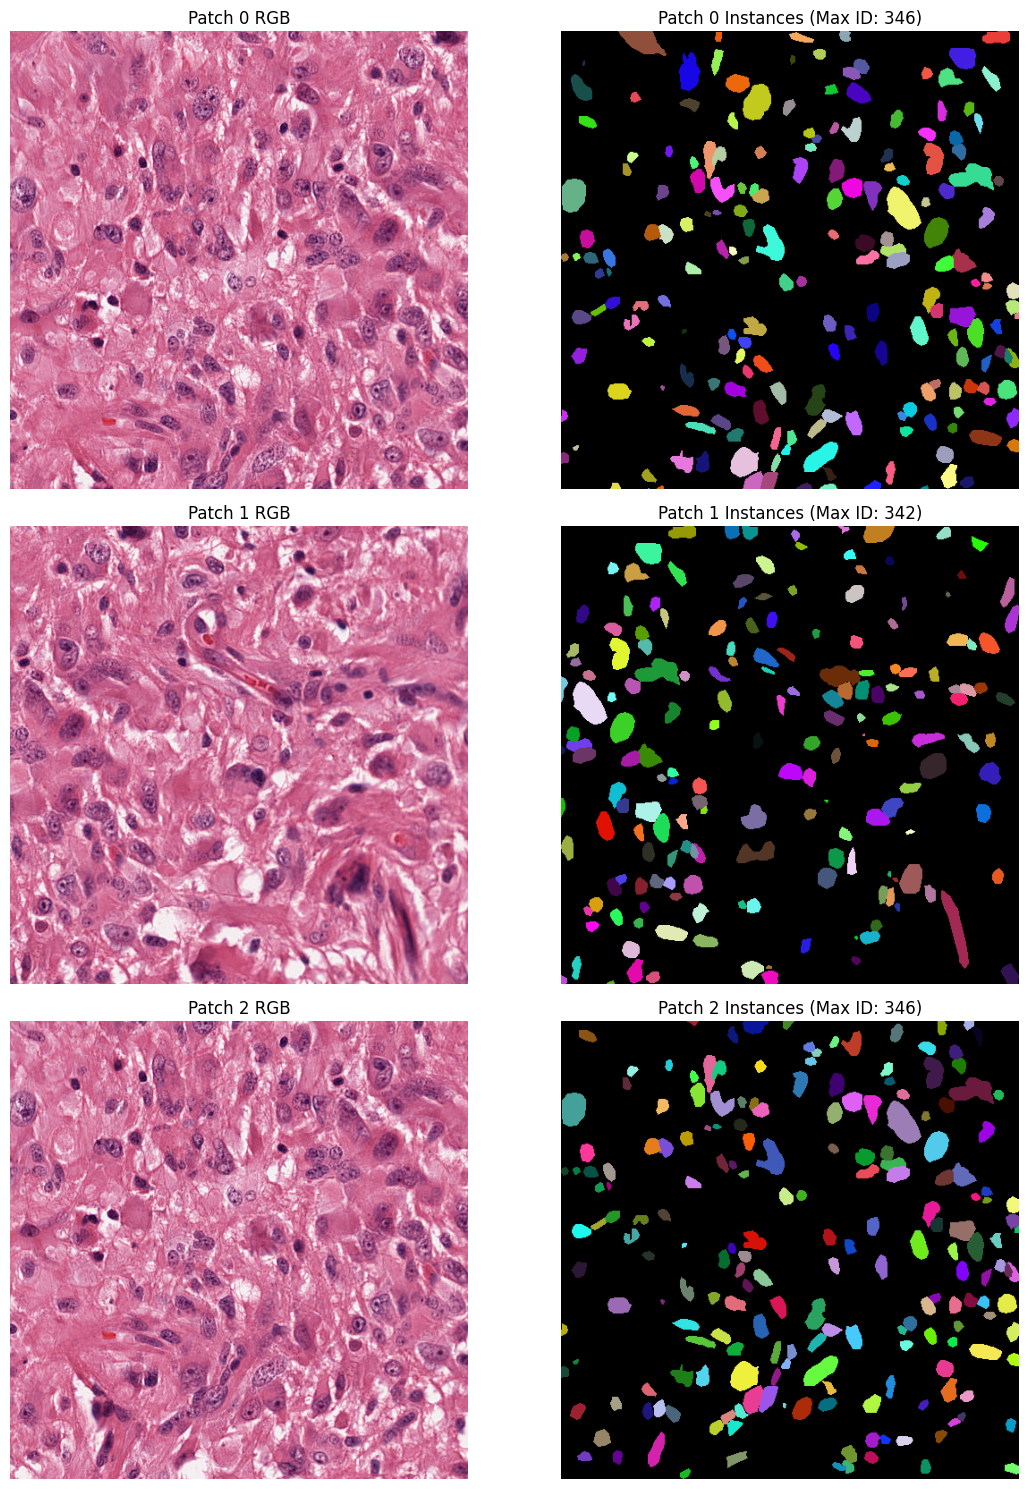

In [12]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
cpm_zarr_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/cpm15/zarr_data")

def get_random_sample(base_path):
    if base_path.exists():
        samples = sorted([d for d in os.listdir(base_path) 
                          if os.path.isdir(base_path / d)])
        if samples:
            # Pick a random sample index
            idx = np.random.randint(0, len(samples))
            return base_path / samples[idx]
    return None

sample_path = get_random_sample(cpm_zarr_path)

# ---------------------------------------------------------------------
# 2. Loading and Random Color Mapping
# ---------------------------------------------------------------------
def colorize_instances(mask):
    max_id = int(mask.max())
    if max_id == 0: return np.zeros((*mask.shape, 3))
    colors = np.random.rand(max_id + 1, 3)
    colors[0] = [0, 0, 0] # Background black
    return colors[mask]

if sample_path:
    print(f"🔎 Inspecting CPM-15 Zarr: {sample_path.name}")
    
    # Open Arrays
    z_img = zarr.open(str(sample_path / 'images.zarr'), mode='r')
    z_nuc = zarr.open(str(sample_path / 'nuclei_masks.zarr'), mode='r')
    
    num_patches = z_img.shape[0]
    print(f"  Stack contains {num_patches} patches.")

    # Visualize up to 3 patches from the stack to see the overlap/crops
    n_to_show = min(3, num_patches)
    fig, axes = plt.subplots(n_to_show, 2, figsize=(12, 5 * n_to_show))
    
    if n_to_show == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n_to_show):
        # Image
        axes[i, 0].imshow(z_img[i])
        axes[i, 0].set_title(f"Patch {i} RGB")
        axes[i, 0].axis('off')
        
        # Mask
        colored_mask = colorize_instances(z_nuc[i])
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title(f"Patch {i} Instances (Max ID: {z_nuc[i].max()})")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No CPM-15 Zarr data found at the specified path.")